In [43]:
## load seq_22612 mutagenesis library + DeepSHAP attributions
## (25k mutants, DeepSHAP w/ 100 dinuc-shuffled background, DeepSTARR Dev task)
## attributions are gradient-corrected (mean-centered across channels) on load.

import h5py
import numpy as np
import pandas as pd

SEQ_LABEL  = '22612'
DATA_DIR   = '/grid/koo/home/pmantill/projects/VBI/init_impliment/data/seq_22612'
LIB_H5     = f'{DATA_DIR}/library_25000.h5'
ATTR_H5    = f'{DATA_DIR}/attributions_deepshap_25000.h5'
NEUTRAL_CSV = '/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/Replicating_Motif_Swap_Manuscript/experimental_library_generation/Binned_libraries/Dev_full_data/mid_df.csv'

def grad_correct(attr):
    """Hypothetical -> grad-corrected: mean-center across the 4-channel axis."""
    return attr - attr.mean(axis=-1, keepdims=True)

with h5py.File(LIB_H5, 'r') as f:
    x_mut = f['sequences'][:]
    y_mut = f['predictions'][:]
print(f'library: x_mut {x_mut.shape}  y_mut {y_mut.shape}  (WT at index 0)')

with h5py.File(ATTR_H5, 'r') as f:
    attributions = grad_correct(f['attributions'][:])
print(f'attributions (grad-corrected): {attributions.shape}')

wt_seq  = x_mut[0]
wt_attr = attributions[0]

neutral_df = pd.read_csv(NEUTRAL_CSV, usecols=['test_idx', 'str_seq'])
print(f'neutral bin: {len(neutral_df)} sequences')

ALPHA_MAP = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
def str_to_onehot(seq_str):
    ohe = np.zeros((len(seq_str), 4), dtype=np.float32)
    for j, b in enumerate(seq_str):
        if b in ALPHA_MAP:
            ohe[j, ALPHA_MAP[b]] = 1.0
    return ohe

def pick_neutral(seed=None):
    """Random row from the neutral bin. Returns (test_idx, str_seq, one_hot)."""
    rng = np.random.default_rng(seed)
    i = int(rng.integers(len(neutral_df)))
    row = neutral_df.iloc[i]
    return int(row['test_idx']), row['str_seq'], str_to_onehot(row['str_seq'])

idx, seq_str, seq_ohe = pick_neutral(seed=0)
print(f'neutral pick: test_idx={idx}  ohe {seq_ohe.shape}')

library: x_mut (25000, 249, 4)  y_mut (25000, 1)  (WT at index 0)
attributions (grad-corrected): (25000, 249, 4)
neutral bin: 3000 sequences
neutral pick: test_idx=18511  ohe (249, 4)


In [44]:
## load bad-case neutral seqs (test_idx 21795, 18511)
## each entry: str_seq, ohe (249,4), attr (Scaled_foreground, grad-corrected)

import re
import numpy as np
import pandas as pd

MID_CSV = '/grid/koo/home/pmantill/projects/Motif_Swap_Experiments/Replicating_Motif_Swap_Manuscript/experimental_library_generation/Binned_libraries/Dev_full_data/mid_df.csv'
BAD_IDS = [21795, 18511]

mid_idx = pd.read_csv(MID_CSV, usecols=['test_idx', 'str_seq', 'real_score', 'evoaug_pred'])

_FLOAT_RE = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')
def parse_tensor_str(s, L=249, A=4):
    vals = _FLOAT_RE.findall(s)
    arr = np.array(vals, dtype=np.float32)
    assert arr.size == L * A, f'got {arr.size} floats, expected {L*A}'
    return arr.reshape(L, A)

def fetch_tensor(row_i, col='Scaled_foreground'):
    sub = pd.read_csv(MID_CSV, usecols=[col],
                      skiprows=lambda r: r != 0 and r != row_i + 1)
    return grad_correct(parse_tensor_str(sub[col].iloc[0]))

bad_cases = {}
for tid in BAD_IDS:
    hits = mid_idx.index[mid_idx['test_idx'] == tid].tolist()
    assert len(hits) == 1, f'test_idx {tid}: {len(hits)} matches'
    row_i = hits[0]
    row = mid_idx.iloc[row_i]
    bad_cases[tid] = {
        'str_seq':     row['str_seq'],
        'ohe':         str_to_onehot(row['str_seq']),
        'attr':        fetch_tensor(row_i, 'Scaled_foreground'),
        'real_score':  float(row['real_score']),
        'evoaug_pred': float(row['evoaug_pred']),
    }
    print(f'bad test_idx={tid}  real={row["real_score"]:.3f}  pred={row["evoaug_pred"]:.3f}  attr {bad_cases[tid]["attr"].shape}')

bad test_idx=21795  real=3.439  pred=0.304  attr (249, 4)
bad test_idx=18511  real=0.060  pred=0.115  attr (249, 4)


In [45]:
print(f"{attributions.shape[0]:,} attribution maps  |  shape per map: {attributions.shape[1:]}")

25,000 attribution maps  |  shape per map: (249, 4)


In [46]:
## VB-GMM from scratch (Dirichlet prior on π, diagonal Gaussians)
## EM: init params → E-step (responsibilities w/ E[log π] from Dirichlet) → M-step (MLE update)

from scipy.special import digamma, gammaln, logsumexp

X = attributions.reshape(attributions.shape[0], -1)          # (N, 4L)  raw attribution scale
N, D = X.shape
print(f"N={N:,}  D={D}  (=4*{D//4})")

def log_gauss_diag(X, mu, log_var, X2=None):
    if X2 is None: X2 = X**2
    precision = np.exp(-log_var)
    log_norm  = -0.5 * (np.log(2*np.pi) + log_var).sum(-1)
    mahal     = (X2 @ precision.T
                 - 2 * X @ (mu * precision).T
                 + (mu**2 * precision).sum(-1))
    return log_norm - 0.5 * mahal

def kl_dirichlet(alpha, alpha0, Elog_pi):
    K = len(alpha)
    return (gammaln(alpha.sum()) - gammaln(alpha).sum()
            - gammaln(K * alpha0) + K * gammaln(alpha0)
            + ((alpha - alpha0) * Elog_pi).sum())

def elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi):
    return logsumexp(log_unnorm, axis=1).sum() - kl_dirichlet(alpha, alpha0, Elog_pi)

K, alpha0 = 150, 1e-10                                       # over-complete; low alpha0 -> prune
rng = np.random.default_rng(0)

alpha   = np.full(K, alpha0 + N / K)
mu      = X[rng.choice(N, K, replace=False)].copy()
log_var = np.full((K, D), np.log(X.var(0).mean() + 1e-8))

# E-step
Elog_pi    = digamma(alpha) - digamma(alpha.sum())
log_unnorm = log_gauss_diag(X, mu, log_var) + Elog_pi
log_r      = log_unnorm - logsumexp(log_unnorm, axis=1, keepdims=True)
r          = np.exp(log_r)

elbo_step1 = elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi)

# M-step
Nk      = r.sum(0)
alpha   = alpha0 + Nk
safe    = np.clip(Nk, 1e-8, None)[:, None]
mu      = (r.T @ X) / safe
log_var = np.log(np.maximum((r.T @ (X**2)) / safe - mu**2, 1e-8))

print(f"ELBO after 1 VB step: {elbo_step1:.3f}")

N=25,000  D=996  (=4*249)
ELBO after 1 VB step: 74421650.521


converged in 188 iters  |  active clusters: 145/150  |  final ELBO: 89304988.770


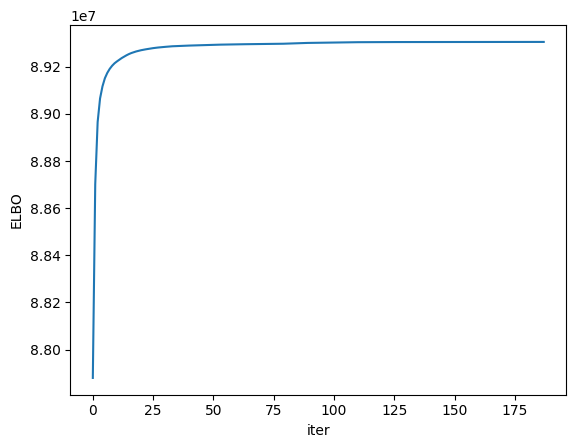

In [47]:
## VB-EM until convergence
import matplotlib.pyplot as plt

X2 = X**2
losses = []

for it in range(200):
    Elog_pi    = digamma(alpha) - digamma(alpha.sum())
    log_unnorm = log_gauss_diag(X, mu, log_var, X2=X2) + Elog_pi
    log_r      = log_unnorm - logsumexp(log_unnorm, axis=1, keepdims=True)
    r          = np.exp(log_r)

    losses.append(elbo_from_logunnorm(log_unnorm, alpha, alpha0, Elog_pi))

    Nk      = r.sum(0)
    alpha   = alpha0 + Nk
    safe    = np.clip(Nk, 1e-8, None)[:, None]
    mu      = (r.T @ X)  / safe
    log_var = np.log(np.maximum((r.T @ X2) / safe - mu**2, 1e-8))

    if it > 0 and abs(losses[-1] - losses[-2]) < 1e-3:
        break

active = int((Nk > 1).sum())
print(f"converged in {len(losses)} iters  |  active clusters: {active}/{K}  |  final ELBO: {losses[-1]:.3f}")
plt.plot(losses); plt.xlabel("iter"); plt.ylabel("ELBO"); plt.show()

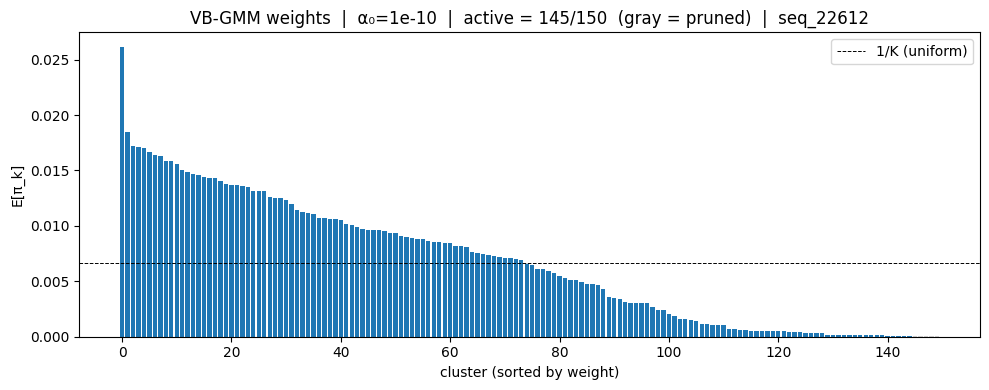

In [48]:
## cluster weights — visualize pruning
E_pi  = alpha / alpha.sum()
order = np.argsort(-E_pi)
active_mask = (Nk > 1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["C0" if active_mask[k] else "lightgray" for k in order]
ax.bar(range(K), E_pi[order], color=colors)
ax.axhline(1/K, ls="--", c="k", lw=0.7, label="1/K (uniform)")
ax.set_xlabel("cluster (sorted by weight)")
ax.set_ylabel("E[π_k]")
ax.set_title(f"VB-GMM weights  |  α₀={alpha0}  |  active = {int(active_mask.sum())}/{K}  (gray = pruned)  |  seq_{SEQ_LABEL}")
ax.legend(); plt.tight_layout(); plt.show()

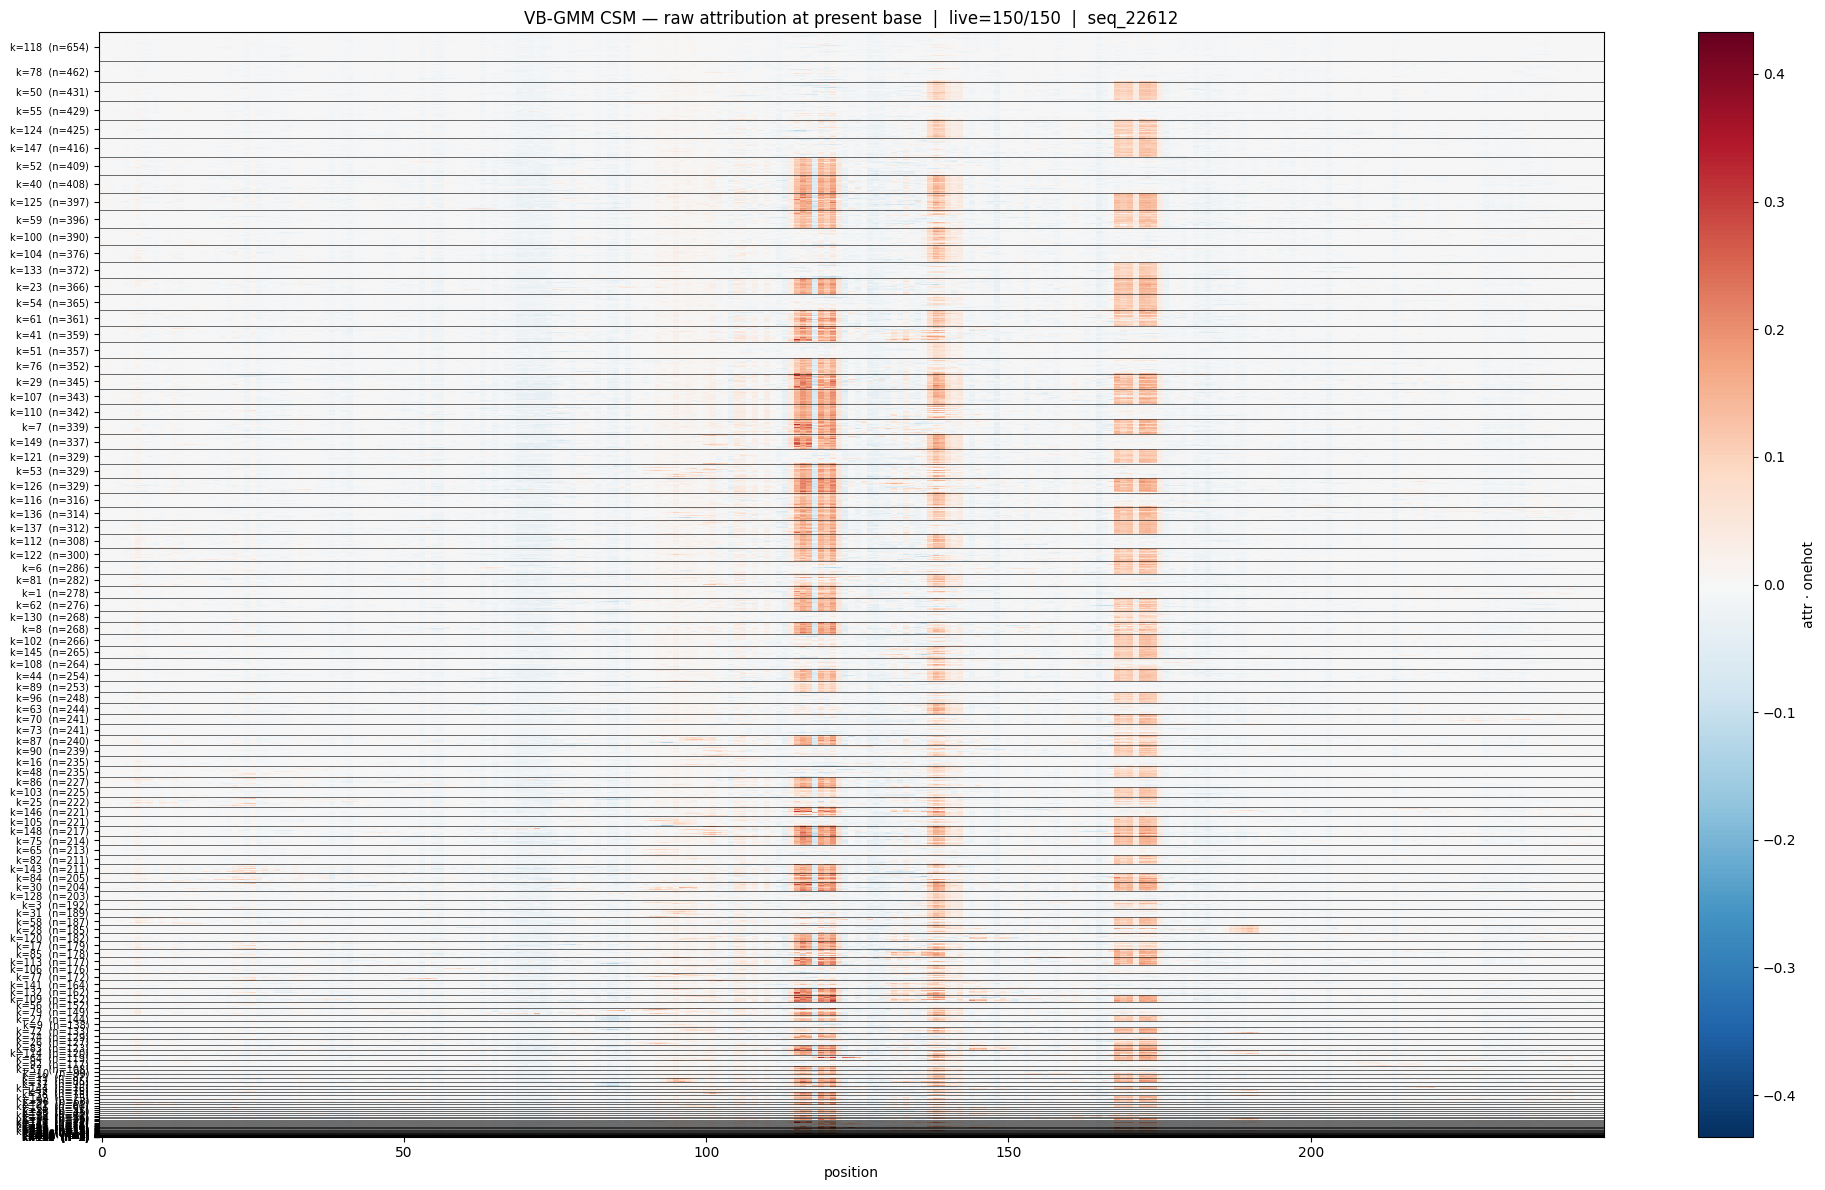

In [49]:
## CSM: rows = seqs in live clusters (counts > 0), ordered by size (largest first), color = raw attribution at the present base
hard         = log_r.argmax(1)
counts       = np.bincount(hard, minlength=K)
live         = np.where(counts > 0)[0]
ranked       = live[np.argsort(-counts[live])]

attr_at_base = (attributions * x_mut).sum(-1)                # (N, L)  raw attribution at the present base

rank_of      = {int(k): i for i, k in enumerate(ranked)}
mask         = np.isin(hard, ranked)
idx          = np.where(mask)[0]
sub_rank     = np.array([rank_of[int(h)] for h in hard[idx]])
row_order    = idx[np.argsort(sub_rank, kind="stable")]
mat          = attr_at_base[row_order]                       # (Σ_live counts, L)

block_sizes  = [counts[k] for k in ranked]
boundaries   = np.cumsum(block_sizes)[:-1]
yticks       = np.cumsum([0] + block_sizes[:-1]) + np.array(block_sizes) / 2
ylabels      = [f"k={k}  (n={counts[k]})" for k in ranked]

vmax = np.abs(mat).max()

fig, ax = plt.subplots(figsize=(20, 12))
im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
for b in boundaries:
    ax.axhline(b, color="k", lw=0.4)
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=7)
ax.set_xlabel("position")
ax.set_title(f"VB-GMM CSM — raw attribution at present base  |  live={len(ranked)}/{K}  |  seq_{SEQ_LABEL}")
plt.colorbar(im, ax=ax, label="attr · onehot"); plt.tight_layout(); plt.show()

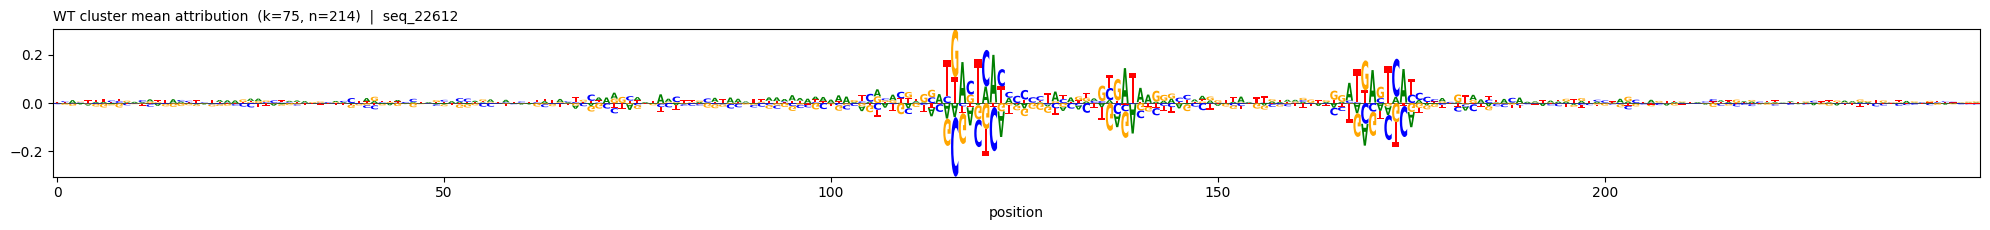

In [50]:
## marginalized attribution map for the WT-containing cluster only
import logomaker
import pandas as pd

wt_k        = int(hard[0])
wt_members  = np.where(hard == wt_k)[0]
wt_cl_mean  = attributions[wt_members].mean(0)                                 # (L, 4)

fig, ax = plt.subplots(figsize=(20, 2.4))
logomaker.Logo(pd.DataFrame(wt_cl_mean, columns=list('ACGT')), ax=ax)
ax.set_title(f"WT cluster mean attribution  (k={wt_k}, n={len(wt_members)})  |  seq_{SEQ_LABEL}",
             fontsize=10, loc='left')
ax.set_xlim(-0.5, wt_cl_mean.shape[0] - 0.5)
ax.set_xlabel('position')
plt.tight_layout(); plt.show()

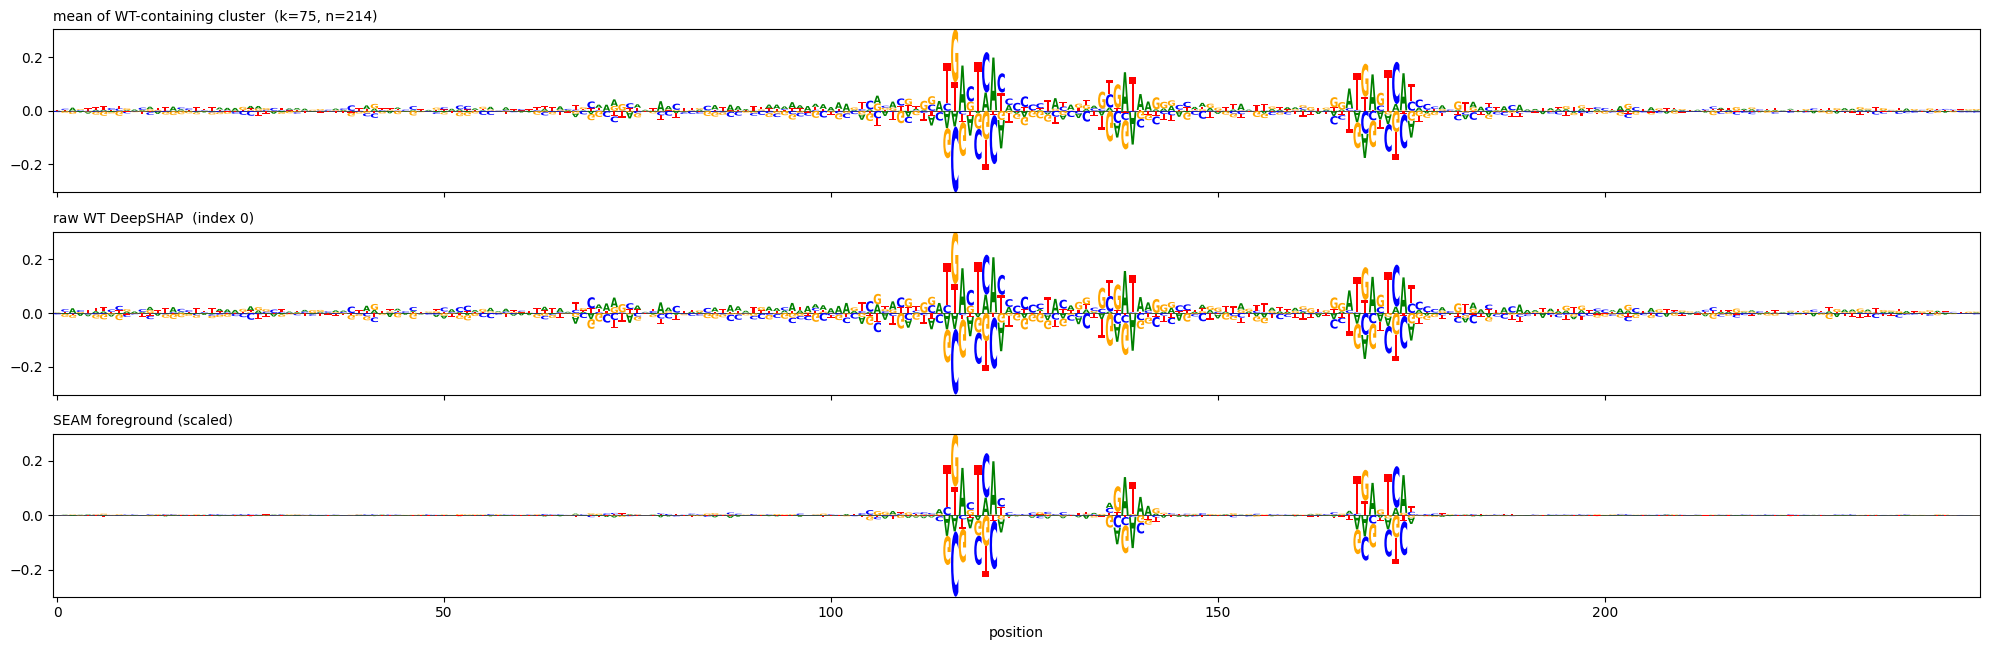

In [51]:
## logos: mean of WT-containing cluster  vs  raw WT DeepSHAP  vs  SEAM foreground (scaled)
import logomaker
import pandas as pd

wt_k        = int(hard[0])
wt_members  = np.where(hard == wt_k)[0]
mean_wt_cl  = attributions[wt_members].mean(0)                                 # (L, 4)
seam_fg     = grad_correct(np.load(f'{DATA_DIR}/foreground_scaled.npy').astype(np.float32))

panels = [
    (f'mean of WT-containing cluster  (k={wt_k}, n={len(wt_members)})', mean_wt_cl),
    ('raw WT DeepSHAP  (index 0)',                                      wt_attr),
    ('SEAM foreground (scaled)',                                        seam_fg),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.2 * len(panels)), sharex=True)
for ax, (title, mat) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(mat, columns=list('ACGT')), ax=ax)
    ax.set_title(title, fontsize=10, loc='left')
    ax.set_xlim(-0.5, mat.shape[0] - 0.5)
axes[-1].set_xlabel('position')
plt.tight_layout(); plt.show()